# Locally resolved expectation values

Beyond spectral (frequency-resolved) quantities, the Chebyshev moments of the local density of
states also give the *ground-state* electronic density at a site directly, by integrating the
local spectral function up to the Fermi level within the same moment expansion --
`kpmtk.densitymatrix_kpm.get_dm_kpm` (the same routine behind the KPM-based mean-field SCF).
Requesting the full diagonal at once gives a real-space map of the local charge density $\langle
n_i\rangle$: below, a strong onsite impurity in a half-filled chain locally depletes the site and
induces decaying Friedel oscillations in its neighbors' occupation -- a ground-state expectation
value, not a spectral profile.

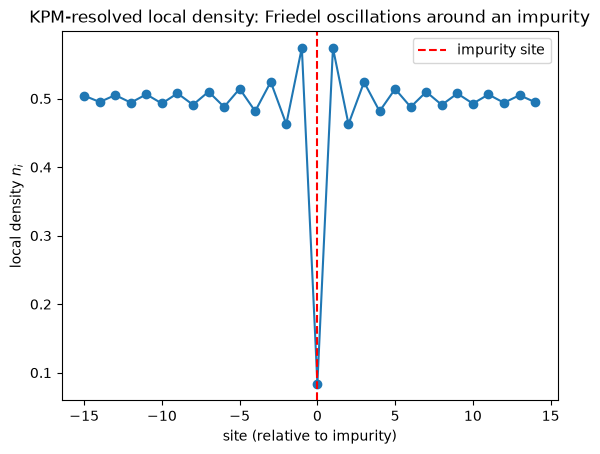

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.kpmtk.densitymatrix_kpm import get_dm_kpm

g = geometry.chain()
g = g.get_supercell(200)
g.dimensionality = 0
h = g.get_hamiltonian(has_spin=False)
imp_i = int(np.argmin(np.abs(g.r[:,0])))
h.add_onsite(lambda r: 3.0 if abs(r[0]-g.r[imp_i,0])<0.1 else 0.0) # single strong impurity

n = len(h.geometry.r)
v = {(0,0,0): np.eye(n)} # request the local density at every site
dm = get_dm_kpm(h,v,nk=1,npol=400,scale=None)
density = np.diag(dm[(0,0,0)]).real

window = slice(imp_i-15,imp_i+15)
plt.plot(np.arange(len(density))[window]-imp_i,density[window],marker="o")
plt.axvline(0,color="red",ls="--",label="impurity site")
plt.xlabel("site (relative to impurity)") ; plt.ylabel("local density $n_i$")
plt.legend()
plt.title("KPM-resolved local density: Friedel oscillations around an impurity")
plt.show()